## Imports + configuration

In [1]:
%pip install tqdm


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import glob
import math
import random
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, random_split

from scipy.sparse import csr_matrix

In [3]:
# ============================================================
# Configuration
# ============================================================

DATASET_DIR = "dataset"

# ------------------------------------------------------------
# Successor Representation cache
# ------------------------------------------------------------

SR_CACHE_DIR = "dataset_sr_gamma090_4x4"

IMAGE_SIZE = 64

BATCH_SIZE = 32
NUM_EPOCHS = 100

LEARNING_RATE = 2e-4

TIMESTEPS = 1000

LATENT_CHANNELS = 16
BASE_CHANNELS = 64

TRAIN_RATIO = 0.9
NUM_WORKERS = 0

SEED = 42

# Weighted x0 reconstruction: background=1, GT path=PATH_WEIGHT
PATH_WEIGHT = 5.0

# ------------------------------------------------------------
# SR configuration
# ------------------------------------------------------------

# random-walk predictive horizon
SR_GAMMA = 0.90

# 4 x 4 fixed spatial regions = 16 successor-feature channels
SR_REGIONS_PER_AXIS = 4
SR_CHANNELS = SR_REGIONS_PER_AXIS ** 2

# Fixed-point iteration:
# Psi_(t+1) = Phi + gamma * P @ Psi_t
SR_MAX_ITER = 300
SR_TOL = 1e-6

# Original 3 map channels + 16 SR channels
MAP_CHANNELS = 3
ENCODER_INPUT_CHANNELS = MAP_CHANNELS + SR_CHANNELS

CHECKPOINT_DIR = "checkpoints_cognitive_SR16_x0+path-weighted"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)
print("SR gamma:", SR_GAMMA)
print("SR channels:", SR_CHANNELS)
print("Encoder input channels:", ENCODER_INPUT_CHANNELS)

Device: cuda
SR gamma: 0.9
SR channels: 16
Encoder input channels: 19


In [4]:
# ============================================================
# Reproducibility
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

## Successor Representation cognitive map

In [5]:
# ============================================================
# Successor Representation utilities
# ============================================================

def build_random_walk_transition_csr(obstacle_map):
    """
    Build sparse random-walk transition matrix P.

    Parameters
    ----------
    obstacle_map : np.ndarray
        Shape [64, 64]
        Dataset convention:
            1 = obstacle
            0 = free

    Returns
    -------
    P : scipy.sparse.csr_matrix
        Shape [4096, 4096]

        For each free cell, transition probability is distributed
        uniformly over legal 4-neighbour free cells.

        Obstacles and isolated free cells use a self-loop.

    Important
    ---------
    Uses ONLY obstacle information.
    No start, goal, or A* path is used.
    """

    obstacle_map = np.asarray(obstacle_map, dtype=np.float32)

    if obstacle_map.ndim != 2:
        raise ValueError(
            f"Expected obstacle map [H,W], got {obstacle_map.shape}"
        )

    H, W = obstacle_map.shape

    if (H, W) != (IMAGE_SIZE, IMAGE_SIZE):
        raise ValueError(
            f"Expected {(IMAGE_SIZE, IMAGE_SIZE)}, got {(H, W)}"
        )

    num_states = H * W

    rows = []
    cols = []
    data = []

    directions = [
        (-1, 0),   # up
        (1, 0),    # down
        (0, -1),   # left
        (0, 1),    # right
    ]

    for r in range(H):
        for c in range(W):

            state = r * W + c

            # Obstacle -> self-loop.
            # Its Phi/Psi values will later be zeroed.
            if obstacle_map[r, c] > 0.5:
                rows.append(state)
                cols.append(state)
                data.append(1.0)
                continue

            neighbours = []

            for dr, dc in directions:
                nr = r + dr
                nc = c + dc

                if not (0 <= nr < H and 0 <= nc < W):
                    continue

                if obstacle_map[nr, nc] > 0.5:
                    continue

                neighbours.append(nr * W + nc)

            # Isolated free state -> self-loop
            if len(neighbours) == 0:
                rows.append(state)
                cols.append(state)
                data.append(1.0)
                continue

            p = 1.0 / len(neighbours)

            for neighbour_state in neighbours:
                rows.append(state)
                cols.append(neighbour_state)
                data.append(p)

    P = csr_matrix(
        (
            np.asarray(data, dtype=np.float32),
            (
                np.asarray(rows, dtype=np.int32),
                np.asarray(cols, dtype=np.int32),
            ),
        ),
        shape=(num_states, num_states),
        dtype=np.float32,
    )

    return P


def build_region_phi(
    obstacle_map,
    regions_per_axis=SR_REGIONS_PER_AXIS,
):
    """
    Build fixed spatial-region feature matrix Phi.

    64x64 grid is divided into a fixed 4x4 layout:

         0   1   2   3
         4   5   6   7
         8   9  10  11
        12  13  14  15

    Each region is 16x16.

    Returns
    -------
    Phi : np.ndarray
        Shape [4096, 16]

        Phi[state, region] = 1 if the free state belongs
        to that region, otherwise 0.

        Obstacle rows are all zero.
    """

    obstacle_map = np.asarray(obstacle_map, dtype=np.float32)
    H, W = obstacle_map.shape

    if H % regions_per_axis != 0 or W % regions_per_axis != 0:
        raise ValueError(
            "Grid size must be divisible by regions_per_axis."
        )

    num_states = H * W
    num_regions = regions_per_axis ** 2

    Phi = np.zeros(
        (num_states, num_regions),
        dtype=np.float32,
    )

    region_h = H // regions_per_axis
    region_w = W // regions_per_axis

    for r in range(H):
        for c in range(W):

            if obstacle_map[r, c] > 0.5:
                continue

            state = r * W + c

            region_row = r // region_h
            region_col = c // region_w

            region_id = (
                region_row * regions_per_axis
                + region_col
            )

            Phi[state, region_id] = 1.0

    return Phi


def compute_successor_features(
    P,
    Phi,
    gamma=SR_GAMMA,
    max_iter=SR_MAX_ITER,
    tol=SR_TOL,
    normalize=True,
):
    """
    Compute successor features without constructing a dense 4096x4096 SR.

    Mathematical target:

        Psi
          = Phi
          + gamma * P Phi
          + gamma^2 * P^2 Phi
          + ...

    Fixed-point equation:

        Psi = Phi + gamma * P Psi

    Iteration:

        Psi_0     = Phi
        Psi_(t+1) = Phi + gamma * P @ Psi_t

    Shapes
    ------
    P   : [4096, 4096] sparse CSR
    Phi : [4096, 16]
    Psi : [4096, 16]

    If normalize=True, multiply by (1-gamma).
    For a free state, the 16 channels then sum approximately to 1.
    """

    if not (0.0 <= gamma < 1.0):
        raise ValueError("gamma must satisfy 0 <= gamma < 1.")

    Psi = Phi.copy()
    final_delta = float("inf")

    for iteration in range(max_iter):

        # Sparse CSR multiplication:
        # only non-zero transitions of P are visited.
        future_features = P @ Psi

        Psi_new = (
            Phi
            + gamma * future_features
        )

        final_delta = float(
            np.max(
                np.abs(Psi_new - Psi)
            )
        )

        Psi = Psi_new

        if final_delta < tol:
            break

    if normalize:
        Psi = (1.0 - gamma) * Psi

    return (
        Psi.astype(np.float32),
        iteration + 1,
        final_delta,
    )


def build_sr_cognitive_map(
    obstacle_map,
    gamma=SR_GAMMA,
    regions_per_axis=SR_REGIONS_PER_AXIS,
    max_iter=SR_MAX_ITER,
    tol=SR_TOL,
    normalize=True,
    return_intermediate=False,
):
    """
    Full conversion:

        obstacle map [64,64]
        -> sparse P [4096,4096]
        -> Phi [4096,16]
        -> Psi [4096,16]
        -> SR cognitive map [16,64,64]
    """

    obstacle_map = np.asarray(
        obstacle_map,
        dtype=np.float32,
    )

    H, W = obstacle_map.shape

    P = build_random_walk_transition_csr(
        obstacle_map
    )

    Phi = build_region_phi(
        obstacle_map,
        regions_per_axis=regions_per_axis,
    )

    Psi, iterations, final_delta = compute_successor_features(
        P=P,
        Phi=Phi,
        gamma=gamma,
        max_iter=max_iter,
        tol=tol,
        normalize=normalize,
    )

    num_regions = regions_per_axis ** 2

    # [4096,16] -> [64,64,16] -> [16,64,64]
    cognitive_map = (
        Psi
        .reshape(H, W, num_regions)
        .transpose(2, 0, 1)
        .copy()
    )

    # Explicitly zero SR features on obstacles.
    obstacle_mask = obstacle_map > 0.5
    cognitive_map[:, obstacle_mask] = 0.0

    cognitive_map = cognitive_map.astype(
        np.float32
    )

    if return_intermediate:
        return {
            "cognitive_map": cognitive_map,
            "P": P,
            "Phi": Phi,
            "Psi": Psi,
            "iterations": iterations,
            "final_delta": final_delta,
        }

    return cognitive_map


# ============================================================
# SR cache
# ============================================================

def precompute_sr_cache(
    dataset_dir,
    cache_dir,
    gamma=SR_GAMMA,
    regions_per_axis=SR_REGIONS_PER_AXIS,
    max_iter=SR_MAX_ITER,
    tol=SR_TOL,
    overwrite=False,
):
    """
    Precompute one SR cognitive map per dataset sample.

    Original sample:
        dataset/pair_00000.npz

    Cached SR:
        cache_dir/pair_00000.npy

    Each cache file has shape:
        [16,64,64]

    Existing valid cache files are skipped unless overwrite=True.
    """

    os.makedirs(
        cache_dir,
        exist_ok=True,
    )

    files = sorted(
        glob.glob(
            os.path.join(
                dataset_dir,
                "pair_*.npz",
            )
        )
    )

    if len(files) == 0:
        raise RuntimeError(
            f"No pair_*.npz files found in {dataset_dir}"
        )

    computed = 0
    skipped = 0

    for filepath in tqdm(
        files,
        desc="Precomputing SR cache",
    ):

        basename = os.path.splitext(
            os.path.basename(filepath)
        )[0]

        cache_path = os.path.join(
            cache_dir,
            basename + ".npy",
        )

        # ----------------------------------------
        # Reuse existing valid cache
        # ----------------------------------------

        if (
            os.path.exists(cache_path)
            and not overwrite
        ):
            try:
                cached = np.load(
                    cache_path,
                    mmap_mode="r",
                )

                expected_shape = (
                    regions_per_axis ** 2,
                    IMAGE_SIZE,
                    IMAGE_SIZE,
                )

                if cached.shape == expected_shape:
                    skipped += 1
                    continue

            except Exception:
                pass

        # ----------------------------------------
        # Load original map
        # ----------------------------------------

        with np.load(filepath) as data:
            grid_map = data["map"].astype(
                np.float32
            )

        if grid_map.shape != (
            3,
            IMAGE_SIZE,
            IMAGE_SIZE,
        ):
            raise ValueError(
                f"{filepath}: unexpected map shape "
                f"{grid_map.shape}"
            )

        obstacle_map = grid_map[0]

        # ----------------------------------------
        # Build SR map
        # ----------------------------------------

        sr_map = build_sr_cognitive_map(
            obstacle_map=obstacle_map,
            gamma=gamma,
            regions_per_axis=regions_per_axis,
            max_iter=max_iter,
            tol=tol,
            normalize=True,
        )

        np.save(
            cache_path,
            sr_map.astype(np.float32),
        )

        computed += 1

    print()
    print("SR cache ready.")
    print("Computed:", computed)
    print("Skipped existing:", skipped)
    print("Cache directory:", cache_dir)


def verify_sr_cache_sample(
    dataset_dir,
    cache_dir,
    sample_index=0,
):
    """
    Sanity-check one cached sample.
    """

    npz_path = os.path.join(
        dataset_dir,
        f"pair_{sample_index:05d}.npz",
    )

    npy_path = os.path.join(
        cache_dir,
        f"pair_{sample_index:05d}.npy",
    )

    with np.load(npz_path) as data:
        grid_map = data["map"].astype(
            np.float32
        )

    sr_map = np.load(
        npy_path
    ).astype(np.float32)

    obstacle = grid_map[0] > 0.5
    free = ~obstacle

    sr_sum = sr_map.sum(axis=0)

    print("Original map:", grid_map.shape)
    print("SR map:", sr_map.shape)

    print(
        "Free-cell SR channel-sum min/max:",
        float(sr_sum[free].min()),
        float(sr_sum[free].max()),
    )

    if obstacle.any():
        print(
            "Obstacle SR absolute max:",
            float(
                np.abs(
                    sr_map[:, obstacle]
                ).max()
            ),
        )

In [6]:
# ============================================================
# Build / reuse SR cache
# ============================================================

precompute_sr_cache(
    dataset_dir=DATASET_DIR,
    cache_dir=SR_CACHE_DIR,
    gamma=SR_GAMMA,
    regions_per_axis=SR_REGIONS_PER_AXIS,
    max_iter=SR_MAX_ITER,
    tol=SR_TOL,
    overwrite=False,
)

verify_sr_cache_sample(
    dataset_dir=DATASET_DIR,
    cache_dir=SR_CACHE_DIR,
    sample_index=0,
)

Precomputing SR cache: 100%|██████████| 10000/10000 [05:24<00:00, 30.79it/s]


SR cache ready.
Computed: 10000
Skipped existing: 0
Cache directory: dataset_sr_gamma090_4x4
Original map: (3, 64, 64)
SR map: (16, 64, 64)
Free-cell SR channel-sum min/max: 0.999999463558197 1.0000001192092896
Obstacle SR absolute max: 0.0


## Dataset loader

In [7]:
class MazePathDataset(Dataset):

    def __init__(
        self,
        dataset_dir,
        sr_cache_dir,
    ):

        self.files = sorted(
            glob.glob(
                os.path.join(
                    dataset_dir,
                    "pair_*.npz",
                )
            )
        )

        self.sr_cache_dir = sr_cache_dir

        if len(self.files) == 0:
            raise RuntimeError(
                f"No .npz files found in {dataset_dir}"
            )

        if not os.path.isdir(
            self.sr_cache_dir
        ):
            raise RuntimeError(
                f"SR cache directory does not exist: "
                f"{self.sr_cache_dir}"
            )

        print(
            f"Found {len(self.files)} samples."
        )

    def __len__(self):
        return len(self.files)

    def __getitem__(
        self,
        idx,
    ):

        filepath = self.files[idx]

        # ========================================
        # Original sample
        # ========================================

        with np.load(filepath) as data:

            grid_map = data["map"].astype(
                np.float32
            )

            path = data["path"].astype(
                np.float32
            )

        if grid_map.shape != (
            3,
            IMAGE_SIZE,
            IMAGE_SIZE,
        ):
            raise ValueError(
                f"{filepath}: unexpected map shape "
                f"{grid_map.shape}"
            )

        # ========================================
        # Precomputed SR cache
        # ========================================

        basename = os.path.splitext(
            os.path.basename(filepath)
        )[0]

        sr_path = os.path.join(
            self.sr_cache_dir,
            basename + ".npy",
        )

        if not os.path.exists(sr_path):
            raise FileNotFoundError(
                f"Missing SR cache: {sr_path}\n"
                f"Run precompute_sr_cache(...) first."
            )

        sr_map = np.load(
            sr_path
        ).astype(np.float32)

        expected_sr_shape = (
            SR_CHANNELS,
            IMAGE_SIZE,
            IMAGE_SIZE,
        )

        if sr_map.shape != expected_sr_shape:
            raise ValueError(
                f"{sr_path}: expected SR shape "
                f"{expected_sr_shape}, got {sr_map.shape}"
            )

        # ========================================
        # Model conditioning input
        #
        # original map:
        #   [3,64,64]
        #
        # SR:
        #   [16,64,64]
        #
        # concatenate:
        #   [19,64,64]
        # ========================================

        model_map = np.concatenate(
            [
                grid_map,
                sr_map,
            ],
            axis=0,
        ).astype(np.float32)

        model_map = torch.from_numpy(
            model_map
        )

        path = torch.from_numpy(
            path
        )

        # Diffusion target:
        # {0,1} -> {-1,1}
        path = path * 2.0 - 1.0

        return {
            "map": model_map,
            "path": path,
        }

## Train / validation split

In [8]:
dataset = MazePathDataset(
    dataset_dir=DATASET_DIR,
    sr_cache_dir=SR_CACHE_DIR,
)

train_size = int(
    len(dataset) * TRAIN_RATIO
)

val_size = (
    len(dataset) - train_size
)

generator = torch.Generator().manual_seed(
    SEED
)

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=generator
)

print(
    "Train:",
    len(train_dataset)
)

print(
    "Validation:",
    len(val_dataset)
)

# One quick shape check
sample0 = dataset[0]

print(
    "Model map shape:",
    sample0["map"].shape
)

print(
    "Path shape:",
    sample0["path"].shape
)

Found 10000 samples.
Train: 9000
Validation: 1000
Model map shape: torch.Size([19, 64, 64])
Path shape: torch.Size([1, 64, 64])


In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

## Cognitive Map Encoder

In [10]:
# ============================================================
# Old local connectivity channels removed
# ============================================================
#
# Previous pipeline:
#
#   [obstacle, start, goal]
#       ->
#   [obstacle, start, goal, up, down, left, right]
#       = 7 channels
#
# New SR pipeline:
#
#   original map [3 channels]
#       +
#   precomputed SR cognitive map [16 channels]
#       =
#   19 channels
#
# The first 3 channels keep exactly the same meaning:
#
#   grid[:, 0] = obstacle
#   grid[:, 1] = start
#   grid[:, 2] = goal
#
# Therefore the existing visualization and evaluation code that
# reads channels 0, 1 and 2 remains compatible.

## CNN Encoder

In [11]:
class CognitiveMapEncoder(nn.Module):

    def __init__(
        self,
        latent_channels=LATENT_CHANNELS,
        input_channels=ENCODER_INPUT_CHANNELS,
    ):

        super().__init__()

        self.encoder = nn.Sequential(

            # Input:
            #   3 original map channels
            # + 16 SR successor-feature channels
            # = 19 channels

            nn.Conv2d(
                input_channels,
                32,
                kernel_size=3,
                padding=1,
            ),

            nn.ReLU(),

            nn.Conv2d(
                32,
                latent_channels,
                kernel_size=3,
                padding=1,
            ),
        )

    def forward(
        self,
        grid,
    ):

        if grid.shape[1] != ENCODER_INPUT_CHANNELS:
            raise ValueError(
                f"Expected {ENCODER_INPUT_CHANNELS} map channels, "
                f"got {grid.shape[1]}"
            )

        return self.encoder(
            grid
        )

## Diffusion timestep embedding

In [12]:
class SinusoidalTimeEmbedding(nn.Module):

    def __init__(self, dim):

        super().__init__()

        self.dim = dim

    def forward(self, time):

        device = time.device

        half_dim = self.dim // 2

        embeddings = math.log(
            10000
        ) / (half_dim - 1)

        embeddings = torch.exp(
            torch.arange(
                half_dim,
                device=device
            )
            * -embeddings
        )

        embeddings = (
            time[:, None].float()
            *
            embeddings[None, :]
        )

        embeddings = torch.cat(
            (
                embeddings.sin(),
                embeddings.cos()
            ),
            dim=1
        )

        return embeddings

## UNet Residual Block

In [13]:
class ResBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        time_dim
    ):

        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.norm1 = nn.GroupNorm(
            8,
            out_channels
        )

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.norm2 = nn.GroupNorm(
            8,
            out_channels
        )

        self.time_mlp = nn.Linear(
            time_dim,
            out_channels
        )

        if in_channels != out_channels:

            self.residual = nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1
            )

        else:

            self.residual = nn.Identity()

    def forward(
        self,
        x,
        time_emb
    ):

        residual = self.residual(x)

        h = self.conv1(x)
        h = self.norm1(h)
        h = F.silu(h)

        # --------------------------------
        # timestep information
        # --------------------------------

        time_feature = self.time_mlp(
            time_emb
        )

        time_feature = time_feature[
            :,
            :,
            None,
            None
        ]

        h = h + time_feature

        h = self.conv2(h)
        h = self.norm2(h)
        h = F.silu(h)

        return h + residual

## Conditional UNet

In [14]:
class ConditionalUNet(nn.Module):

    def __init__(
        self,
        map_latent_channels=16,
        base_channels=64,
        time_dim=256
    ):

        super().__init__()

        input_channels = (
            1 + map_latent_channels
        )

        # ========================================
        # Time embedding
        # ========================================

        self.time_embedding = nn.Sequential(

            SinusoidalTimeEmbedding(
                time_dim
            ),

            nn.Linear(
                time_dim,
                time_dim
            ),

            nn.SiLU(),

            nn.Linear(
                time_dim,
                time_dim
            )
        )

        # ========================================
        # Input
        # ========================================

        self.input_conv = nn.Conv2d(
            input_channels,
            base_channels,
            kernel_size=3,
            padding=1
        )

        # ========================================
        # Encoder
        # ========================================

        self.down1 = ResBlock(
            base_channels,
            base_channels,
            time_dim
        )

        self.pool1 = nn.Conv2d(
            base_channels,
            base_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.down2 = ResBlock(
            base_channels,
            base_channels * 2,
            time_dim
        )

        self.pool2 = nn.Conv2d(
            base_channels * 2,
            base_channels * 2,
            kernel_size=4,
            stride=2,
            padding=1
        )

        # ========================================
        # Bottleneck
        # ========================================

        self.mid1 = ResBlock(
            base_channels * 2,
            base_channels * 4,
            time_dim
        )

        self.mid2 = ResBlock(
            base_channels * 4,
            base_channels * 4,
            time_dim
        )

        # ========================================
        # Decoder
        # ========================================

        self.up2 = nn.ConvTranspose2d(
            base_channels * 4,
            base_channels * 2,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.up_block2 = ResBlock(
            base_channels * 4,
            base_channels * 2,
            time_dim
        )

        self.up1 = nn.ConvTranspose2d(
            base_channels * 2,
            base_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.up_block1 = ResBlock(
            base_channels * 2,
            base_channels,
            time_dim
        )

        # ========================================
        # Output
        # ========================================

        self.output = nn.Conv2d(
            base_channels,
            1,
            kernel_size=1
        )

    def forward(
        self,
        x,
        timestep
    ):

        # timestep embedding
        t = self.time_embedding(
            timestep
        )

        # input
        x = self.input_conv(x)

        # ----------------------------------------
        # Down
        # ----------------------------------------

        skip1 = self.down1(
            x,
            t
        )

        x = self.pool1(
            skip1
        )

        skip2 = self.down2(
            x,
            t
        )

        x = self.pool2(
            skip2
        )

        # ----------------------------------------
        # Middle
        # ----------------------------------------

        x = self.mid1(
            x,
            t
        )

        x = self.mid2(
            x,
            t
        )

        # ----------------------------------------
        # Up
        # ----------------------------------------

        x = self.up2(x)

        x = torch.cat(
            [x, skip2],
            dim=1
        )

        x = self.up_block2(
            x,
            t
        )

        x = self.up1(x)

        x = torch.cat(
            [x, skip1],
            dim=1
        )

        x = self.up_block1(
            x,
            t
        )

        return self.output(x)

## Cognitive Diffusion Model

In [15]:
class CognitiveDiffusionModel(nn.Module):

    def __init__(
        self,
        latent_channels=16,
        base_channels=64
    ):
        super().__init__()

        self.map_encoder = CognitiveMapEncoder(
            latent_channels=latent_channels
        )

        self.unet = ConditionalUNet(
            map_latent_channels=latent_channels,
            base_channels=base_channels
        )

    def encode_map(self, grid_map):
        return self.map_encoder(grid_map)

    def predict_x0(
        self,
        noisy_path,
        map_latent,
        timestep
    ):
        model_input = torch.cat(
            [noisy_path, map_latent],
            dim=1
        )

        predicted_x0 = self.unet(
            model_input,
            timestep
        )

        return predicted_x0

    def forward(
        self,
        grid_map,
        noisy_path,
        timestep
    ):
        map_latent = self.encode_map(grid_map)

        predicted_x0 = self.predict_x0(
            noisy_path,
            map_latent,
            timestep
        )

        return predicted_x0

## DDPM noise schedule

In [16]:
class GaussianDiffusion:

    def __init__(
        self,
        timesteps=1000,
        beta_start=1e-4,
        beta_end=0.02,
        device="cuda"
    ):

        self.timesteps = timesteps
        self.device = device

        # ----------------------------------------
        # Linear beta schedule
        # ----------------------------------------

        self.betas = torch.linspace(
            beta_start,
            beta_end,
            timesteps,
            device=device
        )

        self.alphas = (
            1.0 - self.betas
        )

        self.alpha_cumprod = torch.cumprod(
            self.alphas,
            dim=0
        )

        self.alpha_cumprod_prev = F.pad(
            self.alpha_cumprod[:-1],
            (1, 0),
            value=1.0
        )

        self.sqrt_alpha_cumprod = (
            torch.sqrt(
                self.alpha_cumprod
            )
        )

        self.sqrt_one_minus_alpha_cumprod = (
            torch.sqrt(
                1.0
                -
                self.alpha_cumprod
            )
        )

        self.sqrt_recip_alphas = (
            torch.sqrt(
                1.0 / self.alphas
            )
        )

        # ----------------------------------------
        # Posterior variance
        # ----------------------------------------

        self.posterior_variance = (
            self.betas
            *
            (
                1.0
                -
                self.alpha_cumprod_prev
            )
            /
            (
                1.0
                -
                self.alpha_cumprod
            )
        )

## Helper

In [17]:
def extract(
    values,
    timestep,
    x_shape
):

    batch_size = timestep.shape[0]

    out = values.gather(
        0,
        timestep
    )

    return out.reshape(
        batch_size,
        *((1,) * (len(x_shape) - 1))
    )

## Forward diffusion

In [18]:
def q_sample(
    diffusion,
    x_start,
    timestep,
    noise=None
):

    if noise is None:
        noise = torch.randn_like(
            x_start
        )

    sqrt_alpha_cumprod_t = extract(
        diffusion.sqrt_alpha_cumprod,
        timestep,
        x_start.shape
    )

    sqrt_one_minus_alpha_cumprod_t = (
        extract(
            diffusion.sqrt_one_minus_alpha_cumprod,
            timestep,
            x_start.shape
        )
    )

    noisy_path = (
        sqrt_alpha_cumprod_t
        *
        x_start

        +

        sqrt_one_minus_alpha_cumprod_t
        *
        noise
    )

    return noisy_path, noise

## Initialize model

In [19]:
model = CognitiveDiffusionModel(
    latent_channels=LATENT_CHANNELS,
    base_channels=BASE_CHANNELS
).to(DEVICE)

In [20]:
diffusion = GaussianDiffusion(
    timesteps=TIMESTEPS,
    device=DEVICE
)

In [21]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

In [22]:
num_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Trainable parameters: "
    f"{num_parameters:,}"
)

Trainable parameters: 4,365,457


## Shape sanity check

In [23]:
batch = next(
    iter(train_loader)
)

grid_map = batch["map"].to(
    DEVICE
)

path = batch["path"].to(
    DEVICE
)

print(
    "Map:",
    grid_map.shape
)

print(
    "Path:",
    path.shape
)

Map: torch.Size([32, 19, 64, 64])
Path: torch.Size([32, 1, 64, 64])


In [24]:
with torch.no_grad():

    batch = next(
        iter(train_loader)
    )

    grid_map = batch["map"].to(
        DEVICE
    )

    print(
        "Conditioning input:",
        grid_map.shape
    )

    test_encoder = CognitiveMapEncoder(
        latent_channels=LATENT_CHANNELS
    ).to(DEVICE)

    map_latent = test_encoder(
        grid_map
    )

    print(
        "Encoded cognitive map:",
        map_latent.shape
    )

    del test_encoder
    del map_latent


Conditioning input: torch.Size([32, 19, 64, 64])
Encoded cognitive map: torch.Size([32, 16, 64, 64])


In [25]:
with torch.no_grad():

    latent = model.encode_map(
        grid_map
    )

print(
    "Cognitive latent:",
    latent.shape
)

Cognitive latent: torch.Size([32, 16, 64, 64])


In [26]:
t = torch.randint(
    0,
    TIMESTEPS,
    (grid_map.shape[0],),
    device=DEVICE
)

noisy_path, _ = q_sample(
    diffusion,
    path,
    t
)

print(
    "Noisy path:",
    noisy_path.shape
)

predicted_x0 = model(
    grid_map,
    noisy_path,
    t
)

print(
    "Predicted x0:",
    predicted_x0.shape
)

Noisy path: torch.Size([32, 1, 64, 64])
Predicted x0: torch.Size([32, 1, 64, 64])


## Training function

In [27]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    diffusion,
    device
):

    model.train()

    total_loss = 0.0

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for batch in progress_bar:

        grid_map = batch["map"].to(
            device,
            non_blocking=True
        )

        path = batch["path"].to(
            device,
            non_blocking=True
        )

        batch_size = path.shape[0]

        # ----------------------------------------
        # Random timestep
        # ----------------------------------------

        timestep = torch.randint(
            0,
            diffusion.timesteps,
            (batch_size,),
            device=device
        ).long()

        # ----------------------------------------
        # Forward diffusion
        #
        # path = clean x0
        # noisy_path = x_t
        # ----------------------------------------

        noisy_path, _ = q_sample(
            diffusion,
            path,
            timestep
        )

        # ----------------------------------------
        # Predict clean x0
        # ----------------------------------------

        predicted_x0 = model(
            grid_map,
            noisy_path,
            timestep
        )

        # ============================================================
        # Weighted x0 reconstruction loss
        # ============================================================

        path_mask = (
            path > 0
        ).float()

        weights = (
            1.0
            +
            (PATH_WEIGHT - 1.0)
            *
            path_mask
        )

        squared_error = (
            predicted_x0
            -
            path
        ).pow(2)

        loss = (
            weights
            *
            squared_error
        ).mean()

        optimizer.zero_grad(
            set_to_none=True
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return (
        total_loss
        /
        len(loader)
    )

## Validation function

In [28]:
@torch.no_grad()
def validate(
    model,
    loader,
    diffusion,
    device
):

    model.eval()

    total_loss = 0.0

    for batch in loader:

        grid_map = batch["map"].to(
            device,
            non_blocking=True
        )

        path = batch["path"].to(
            device,
            non_blocking=True
        )

        batch_size = path.shape[0]

        timestep = torch.randint(
            0,
            diffusion.timesteps,
            (batch_size,),
            device=device
        ).long()

        # ----------------------------------------
        # Forward diffusion
        # ----------------------------------------

        noisy_path, _ = q_sample(
            diffusion,
            path,
            timestep
        )

        predicted_x0 = model(
            grid_map,
            noisy_path,
            timestep
        )

        path_mask = (
            path > 0
        ).float()

        weights = (
            1.0
            +
            (PATH_WEIGHT - 1.0)
            *
            path_mask
        )

        squared_error = (
            predicted_x0
            -
            path
        ).pow(2)

        loss = (
            weights
            *
            squared_error
        ).mean()

        total_loss += loss.item()

    return (
        total_loss
        /
        len(loader)
    )

## Full training loop

In [29]:
best_val_loss = float("inf")

train_losses = []
val_losses = []


for epoch in range(
    1,
    NUM_EPOCHS + 1
):

    print(
        f"\nEpoch "
        f"{epoch}/{NUM_EPOCHS}"
    )

    # ========================================
    # Training
    # ========================================

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        diffusion,
        DEVICE
    )

    # ========================================
    # Validation
    # ========================================

    val_loss = validate(
        model,
        val_loader,
        diffusion,
        DEVICE
    )

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )

    print(
        f"Train loss: "
        f"{train_loss:.6f}"
    )

    print(
        f"Val loss:   "
        f"{val_loss:.6f}"
    )

    # ========================================
    # Save latest
    # ========================================

    checkpoint = {

        "epoch":
            epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "train_loss":
            train_loss,

        "val_loss":
            val_loss,

        "config": {

            "timesteps":
                TIMESTEPS,

            "latent_channels":
                LATENT_CHANNELS,

            "base_channels":
                BASE_CHANNELS,

            "prediction_target":
                "x0",

            "path_weight":
                PATH_WEIGHT,

            "cognitive_map":
                "random_walk_successor_features",

            "sr_gamma":
                SR_GAMMA,

            "sr_regions_per_axis":
                SR_REGIONS_PER_AXIS,

            "sr_channels":
                SR_CHANNELS
        }
    }

    torch.save(
        checkpoint,
        os.path.join(
            CHECKPOINT_DIR,
            "latest.pt"
        )
    )

    # ========================================
    # Save best
    # ========================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            checkpoint,
            os.path.join(
                CHECKPOINT_DIR,
                "best.pt"
            )
        )

        print(
            "Saved new best model."
        )


Epoch 1/100


Train loss: 0.231628
Val loss:   0.182056
Saved new best model.

Epoch 2/100


Train loss: 0.163985
Val loss:   0.150169
Saved new best model.

Epoch 3/100


Train loss: 0.142497
Val loss:   0.145032
Saved new best model.

Epoch 4/100


Train loss: 0.127539
Val loss:   0.133402
Saved new best model.

Epoch 5/100


...

Train loss: 0.004003
Val loss:   0.102824

Epoch 97/100


Train loss: 0.003076
Val loss:   0.118348

Epoch 98/100


Train loss: 0.002408
Val loss:   0.122452

Epoch 99/100


Train loss: 0.003748
Val loss:   0.110429

Epoch 100/100


Train loss: 0.003651
Val loss:   0.115145


## Plot loss curve

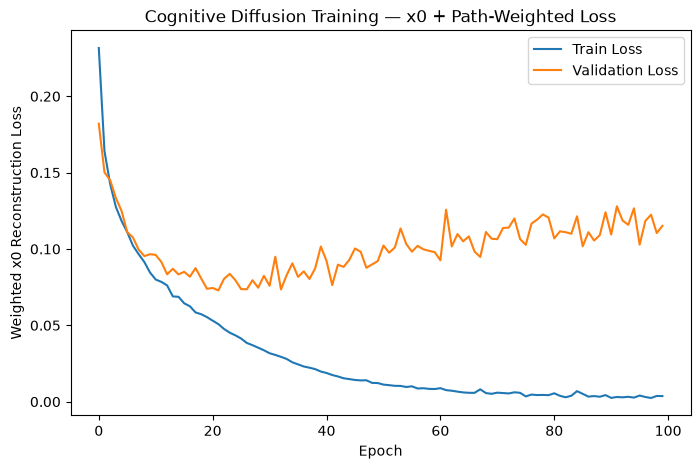

In [30]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Weighted x0 Reconstruction Loss"
)

plt.title(
    "Cognitive Diffusion Training — x0 + Path-Weighted Loss"
)

plt.legend()

plt.show()

## Reverse diffusion / inference

In [31]:
@torch.no_grad()
def p_sample(
    model,
    diffusion,
    x,
    map_latent,
    timestep,
    timestep_index
):

    # ========================================
    # Predict clean x0
    # ========================================

    predicted_x0 = model.predict_x0(
        x,
        map_latent,
        timestep
    )

    # Keep prediction in training data range
    predicted_x0 = torch.clamp(
        predicted_x0,
        -1.0,
        1.0
    )

    # ========================================
    # Extract diffusion coefficients
    # ========================================

    beta_t = extract(
        diffusion.betas,
        timestep,
        x.shape
    )

    alpha_t = extract(
        diffusion.alphas,
        timestep,
        x.shape
    )

    alpha_cumprod_t = extract(
        diffusion.alpha_cumprod,
        timestep,
        x.shape
    )

    alpha_cumprod_prev_t = extract(
        diffusion.alpha_cumprod_prev,
        timestep,
        x.shape
    )

    # ========================================
    # Posterior mean:
    #
    # q(x_{t-1} | x_t, x0)
    # ========================================

    coefficient_x0 = (
        torch.sqrt(
            alpha_cumprod_prev_t
        )
        *
        beta_t
        /
        (
            1.0
            -
            alpha_cumprod_t
        )
    )

    coefficient_xt = (
        torch.sqrt(
            alpha_t
        )
        *
        (
            1.0
            -
            alpha_cumprod_prev_t
        )
        /
        (
            1.0
            -
            alpha_cumprod_t
        )
    )

    model_mean = (
        coefficient_x0
        *
        predicted_x0
        +
        coefficient_xt
        *
        x
    )

    # ========================================
    # Final step: no additional noise
    # ========================================

    if timestep_index == 0:
        return model_mean

    # ========================================
    # Posterior variance
    # ========================================

    posterior_variance_t = extract(
        diffusion.posterior_variance,
        timestep,
        x.shape
    )

    noise = torch.randn_like(
        x
    )

    return (
        model_mean
        +
        torch.sqrt(
            posterior_variance_t
        )
        *
        noise
    )

In [32]:
@torch.no_grad()
def sample_path(
    model,
    diffusion,
    grid_map,
    device
):

    model.eval()

    grid_map = grid_map.to(
        device
    )

    if grid_map.dim() == 3:
        grid_map = grid_map.unsqueeze(0)

    batch_size = grid_map.shape[0]

    # ========================================
    # Encode map ONCE
    # ========================================

    map_latent = model.encode_map(
        grid_map
    )

    # ========================================
    # Start from pure Gaussian noise
    # ========================================

    x = torch.randn(
        batch_size,
        1,
        IMAGE_SIZE,
        IMAGE_SIZE,
        device=device
    )

    # ========================================
    # Reverse diffusion
    # ========================================

    for i in tqdm(
        reversed(
            range(
                diffusion.timesteps
            )
        ),
        total=diffusion.timesteps,
        desc="Sampling"
    ):

        timestep = torch.full(
            (batch_size,),
            i,
            device=device,
            dtype=torch.long
        )

        x = p_sample(
            model,
            diffusion,
            x,
            map_latent,
            timestep,
            i
        )

    # ========================================
    # [-1,1] → [0,1]
    # ========================================

    x = (
        x + 1.0
    ) / 2.0

    x = torch.clamp(
        x,
        0.0,
        1.0
    )

    return x

## Load best model

In [33]:
checkpoint = torch.load(
    os.path.join(
        CHECKPOINT_DIR,
        "best.pt"
    ),
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

model.eval()

print(
    "Loaded epoch:",
    checkpoint["epoch"]
)

print(
    "Validation loss:",
    checkpoint["val_loss"]
)

Loaded epoch: 22
Validation loss: 0.07287211541552097


/tmp/ipykernel_771/221025179.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


## Predict on validation sample

In [34]:
import matplotlib.pyplot as plt
import numpy as np


@torch.no_grad()
def visualize_samples(
    model,
    diffusion,
    dataset,
    indices,
    device
):
    """
    Visualize multiple validation samples.

    Each row:
        Input Map | A* Ground Truth | Diffusion Prediction
    """

    num_samples = len(indices)

    fig, axes = plt.subplots(
        num_samples,
        3,
        figsize=(15, 5 * num_samples)
    )

    # If only one sample is requested,
    # make axes 2D for consistent indexing
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(indices):

        # ========================================
        # Load sample
        # ========================================

        sample = dataset[idx]

        grid_map = sample["map"]
        ground_truth = sample["path"]

        # [-1, 1] -> [0, 1]
        ground_truth_01 = (
            ground_truth + 1.0
        ) / 2.0

        # ========================================
        # Diffusion inference
        # ========================================

        predicted_path = sample_path(
            model,
            diffusion,
            grid_map,
            device
        )

        # ========================================
        # Extract map channels
        # ========================================

        obstacle = grid_map[0].cpu().numpy()
        start_map = grid_map[1].cpu().numpy()
        goal_map = grid_map[2].cpu().numpy()

        gt = ground_truth_01[0].cpu().numpy()

        pred = (
            predicted_path[0, 0]
            .cpu()
            .numpy()
        )

        binary_pred = pred > 0.5

        # ========================================
        # Start / goal coordinates
        # ========================================

        start_y, start_x = np.where(
            start_map > 0.5
        )

        goal_y, goal_x = np.where(
            goal_map > 0.5
        )

        # ========================================
        # Ground-truth coordinates
        # ========================================

        gt_y, gt_x = np.where(
            gt > 0.5
        )

        # ========================================
        # Prediction coordinates
        # ========================================

        pred_y, pred_x = np.where(
            binary_pred
        )

        # ========================================
        # Column 1: Input Map
        # ========================================

        ax = axes[row, 0]

        ax.imshow(
            obstacle,
            cmap="gray_r"
        )

        ax.scatter(
            start_x,
            start_y,
            marker="o",
            s=80,
            label="Start"
        )

        ax.scatter(
            goal_x,
            goal_y,
            marker="*",
            s=120,
            label="Goal"
        )

        ax.set_title(
            f"Sample {idx} — Input Map"
        )

        ax.axis("off")

        if row == 0:
            ax.legend()

        # ========================================
        # Column 2: A* Ground Truth
        # ========================================

        ax = axes[row, 1]

        ax.imshow(
            obstacle,
            cmap="gray_r"
        )

        ax.scatter(
            gt_x,
            gt_y,
            s=8
        )

        ax.scatter(
            start_x,
            start_y,
            marker="o",
            s=80
        )

        ax.scatter(
            goal_x,
            goal_y,
            marker="*",
            s=120
        )

        ax.set_title(
            f"Sample {idx} — A* Ground Truth"
        )

        ax.axis("off")

        # ========================================
        # Column 3: Diffusion Prediction
        # ========================================

        ax = axes[row, 2]

        ax.imshow(
            obstacle,
            cmap="gray_r"
        )

        ax.scatter(
            pred_x,
            pred_y,
            s=8
        )

        ax.scatter(
            start_x,
            start_y,
            marker="o",
            s=80
        )

        ax.scatter(
            goal_x,
            goal_y,
            marker="*",
            s=120
        )

        ax.set_title(
            f"Sample {idx} — Diffusion Prediction"
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

Sampling: 100%|██████████| 1000/1000 [00:02<00:00, 428.30it/s]


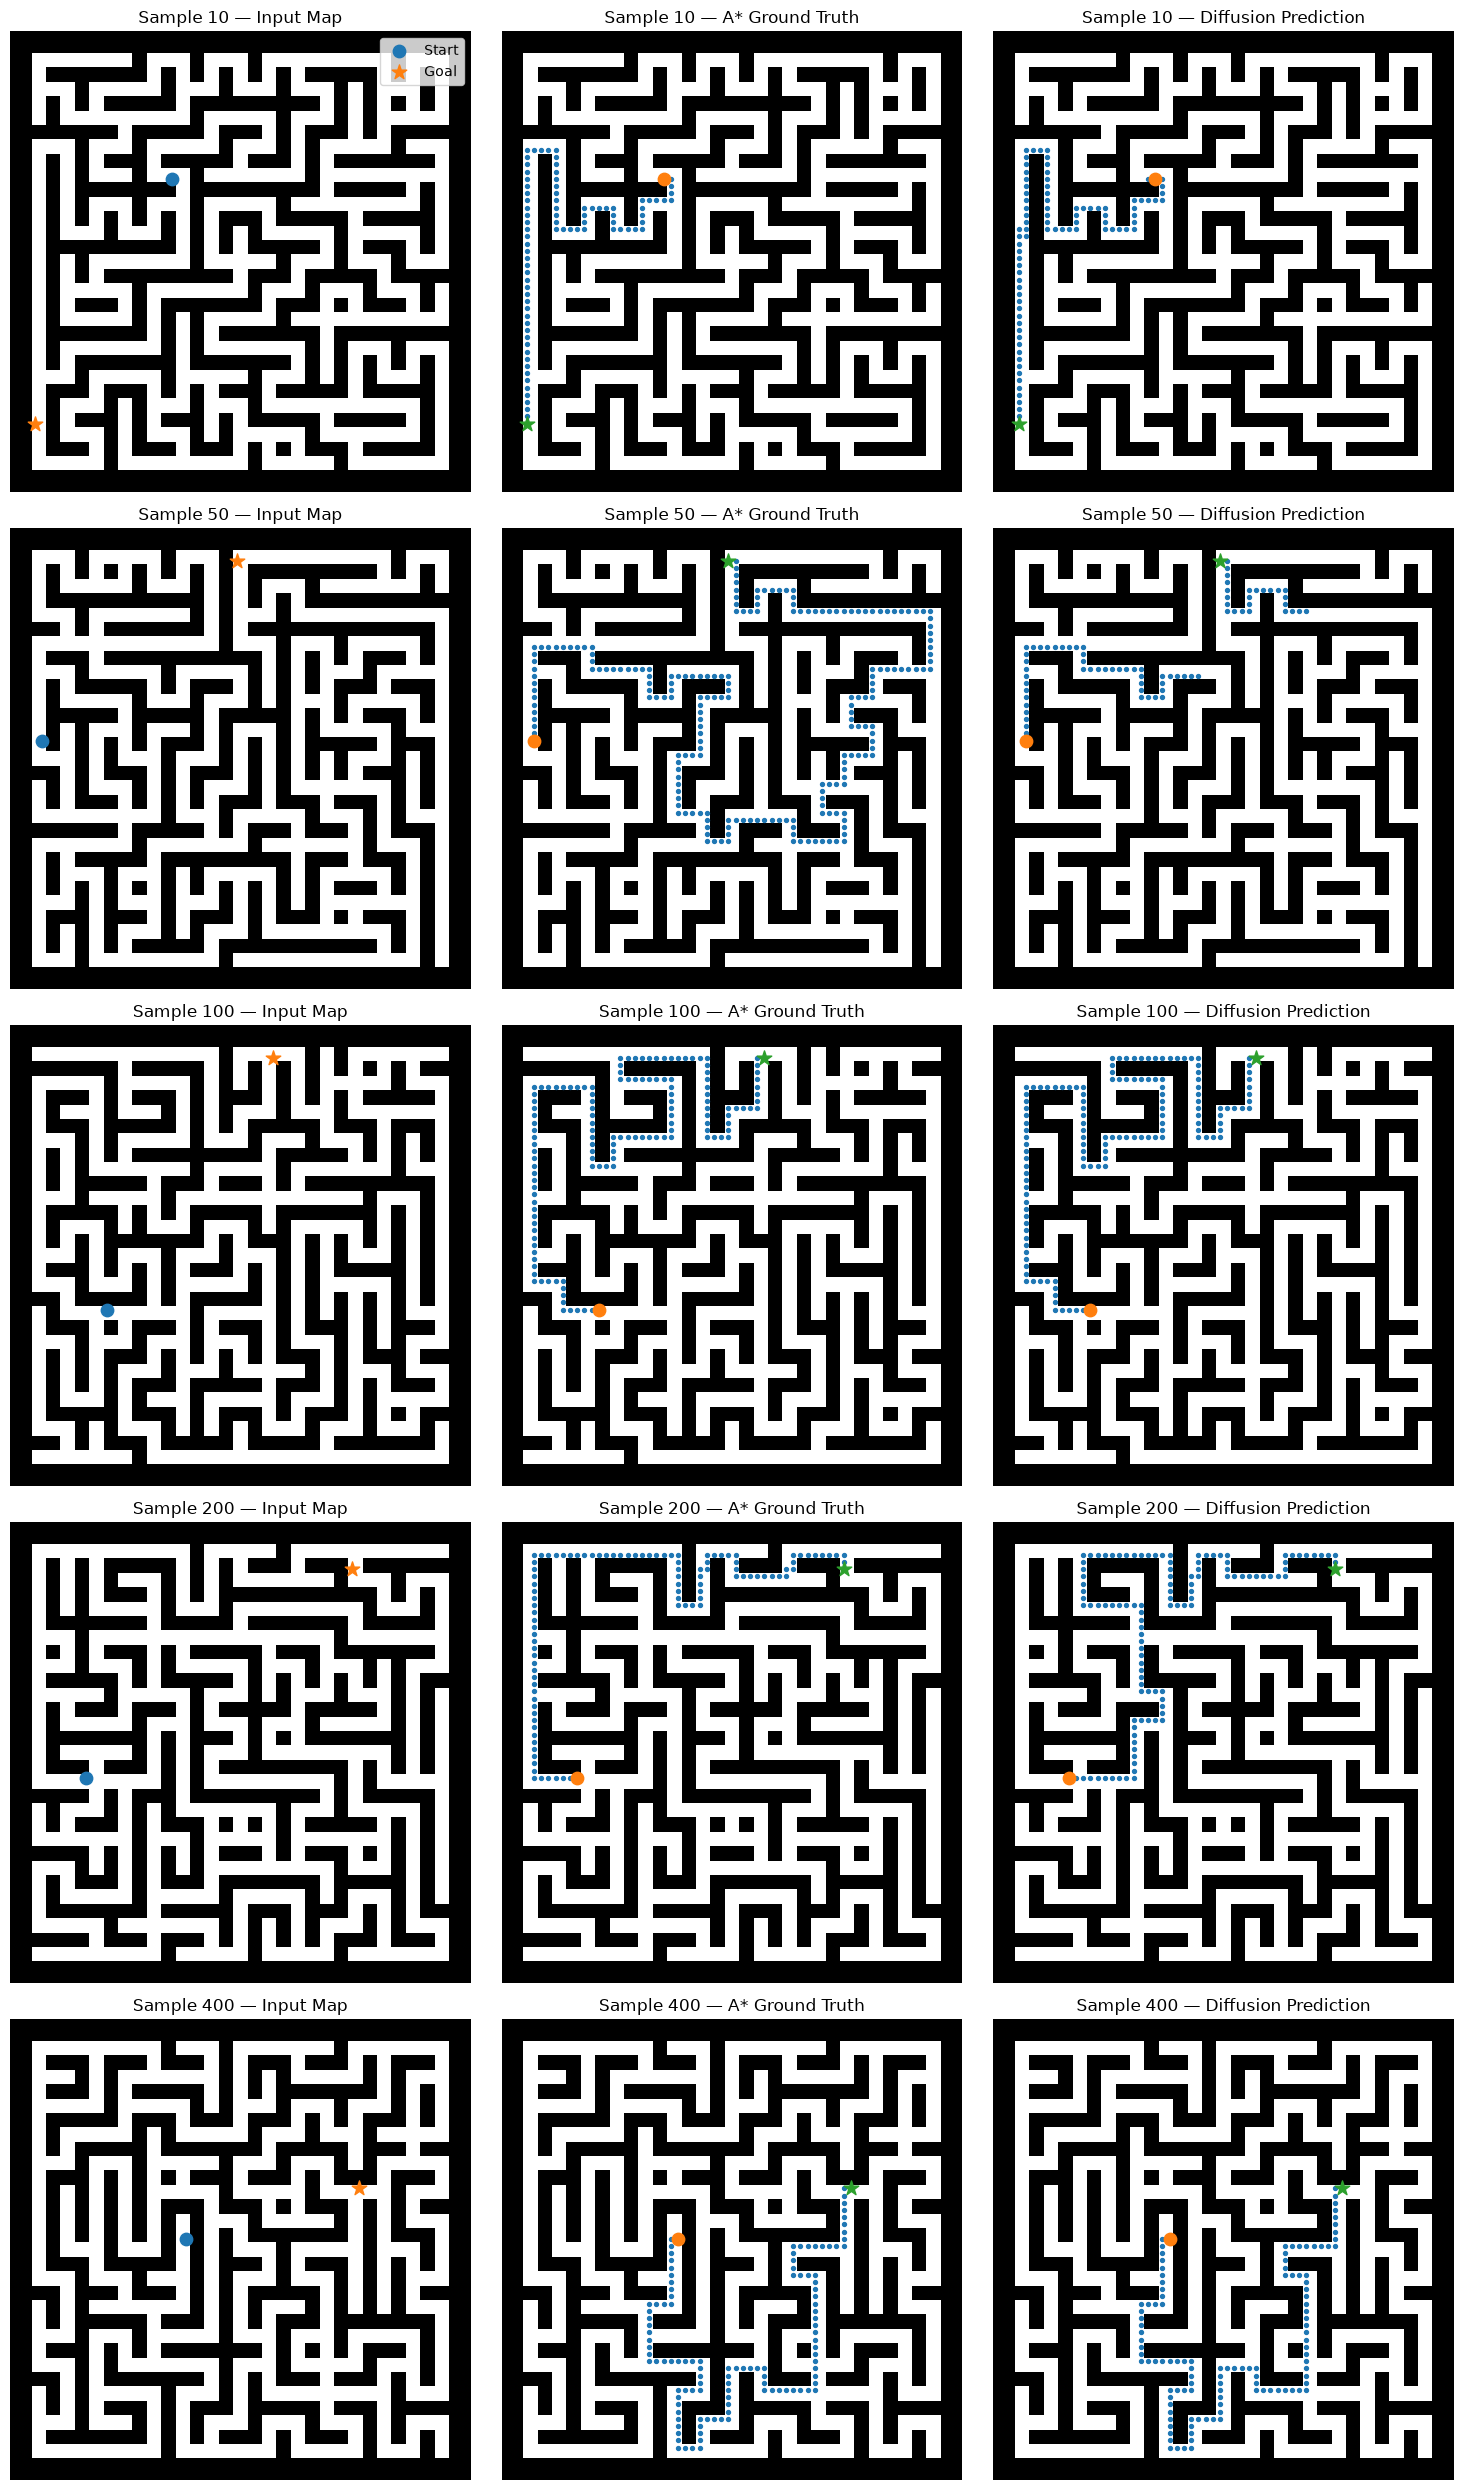

In [35]:
visualize_samples(
    model=model,
    diffusion=diffusion,
    dataset=val_dataset,
    indices=[10, 50, 100, 200, 400],
    device=DEVICE
)

Testing samples: [521, 737, 740, 660, 411, 678, 626, 513, 859, 136]


Sampling: 100%|██████████| 1000/1000 [00:02<00:00, 427.78it/s]


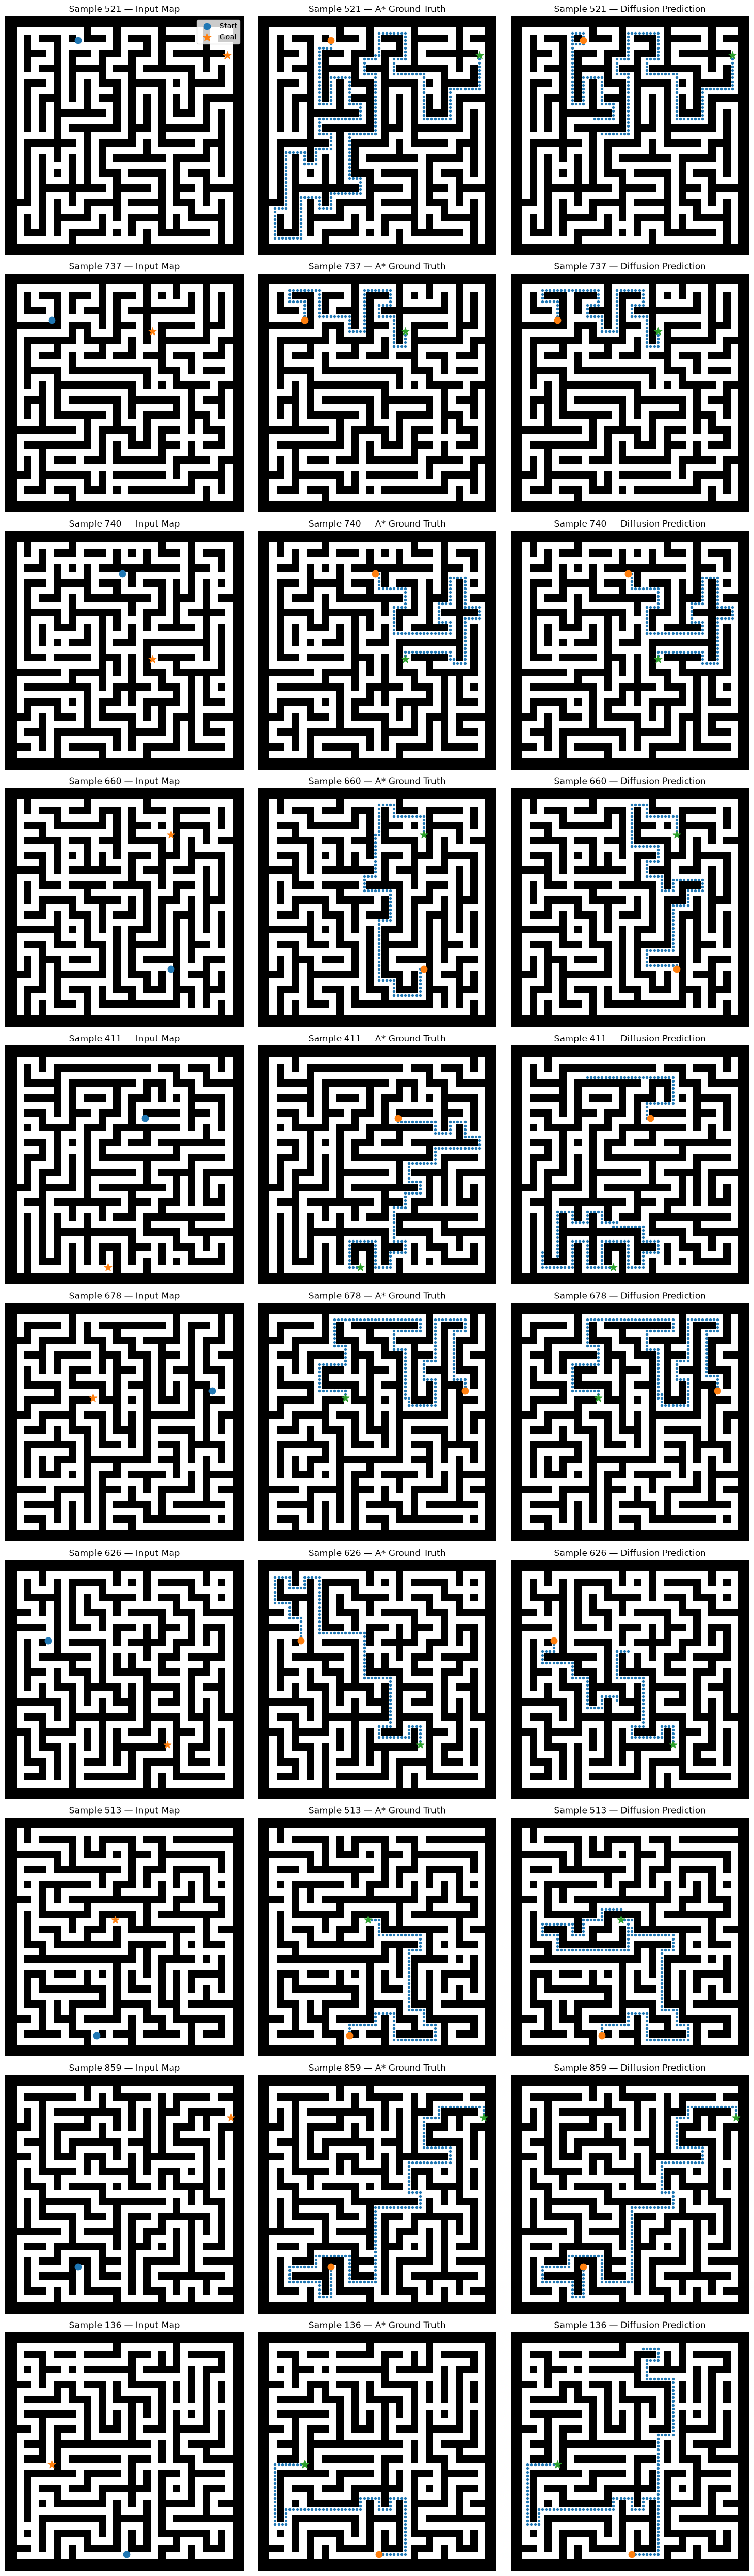

In [36]:
indices = np.random.choice(
    len(val_dataset),
    size=10,
    replace=False
).tolist()

print("Testing samples:", indices)

visualize_samples(
    model=model,
    diffusion=diffusion,
    dataset=val_dataset,
    indices=indices,
    device=DEVICE
)

## Validation evaluator

In [37]:
import numpy as np
import torch
from collections import deque
from tqdm.auto import tqdm

In [38]:
def check_4neighbor_connection(
    binary_path,
    start,
    goal
):
    """
    binary_path: numpy array [H, W], bool
    start: (y, x)
    goal: (y, x)

    Returns:
        True if goal is reachable from start
        using only 4-neighbor path pixels.
    """

    H, W = binary_path.shape

    sy, sx = start
    gy, gx = goal

    # start / goal must both belong to path
    if not binary_path[sy, sx]:
        return False

    if not binary_path[gy, gx]:
        return False

    visited = np.zeros(
        (H, W),
        dtype=bool
    )

    queue = deque()

    queue.append(
        (sy, sx)
    )

    visited[sy, sx] = True

    directions = [
        (-1, 0),   # up
        (1, 0),    # down
        (0, -1),   # left
        (0, 1)     # right
    ]

    while queue:

        y, x = queue.popleft()

        # reached goal
        if (y, x) == (gy, gx):
            return True

        for dy, dx in directions:

            ny = y + dy
            nx = x + dx

            if (
                0 <= ny < H
                and
                0 <= nx < W
            ):

                if (
                    binary_path[ny, nx]
                    and
                    not visited[ny, nx]
                ):

                    visited[ny, nx] = True

                    queue.append(
                        (ny, nx)
                    )

    return False

In [39]:
@torch.no_grad()
def evaluate_single_sample(
    model,
    diffusion,
    sample,
    device,
    threshold=0.5
):
    """
    Evaluate one generated path.

    Returns dictionary with:
        start_in_path
        goal_in_path
        collision_free
        connected
    """

    grid_map = sample["map"]

    # ========================================
    # Generate predicted path
    # ========================================

    predicted_path = sample_path(
        model,
        diffusion,
        grid_map,
        device
    )

    pred = (
        predicted_path[0, 0]
        .cpu()
        .numpy()
    )

    binary_path = (
        pred > threshold
    )

    # ========================================
    # Extract map channels
    # ========================================

    obstacle = (
        grid_map[0]
        .cpu()
        .numpy()
        > 0.5
    )

    start_map = (
        grid_map[1]
        .cpu()
        .numpy()
        > 0.5
    )

    goal_map = (
        grid_map[2]
        .cpu()
        .numpy()
        > 0.5
    )

    # ========================================
    # Find start / goal
    # ========================================

    start_y, start_x = np.where(
        start_map
    )

    goal_y, goal_x = np.where(
        goal_map
    )

    if len(start_y) != 1:
        raise ValueError(
            "Expected exactly one start cell."
        )

    if len(goal_y) != 1:
        raise ValueError(
            "Expected exactly one goal cell."
        )

    start = (
        int(start_y[0]),
        int(start_x[0])
    )

    goal = (
        int(goal_y[0]),
        int(goal_x[0])
    )

    # ========================================
    # Metric 1:
    # Start included?
    # ========================================

    sy, sx = start

    start_in_path = bool(
        binary_path[sy, sx]
    )

    # ========================================
    # Metric 2:
    # Goal included?
    # ========================================

    gy, gx = goal

    goal_in_path = bool(
        binary_path[gy, gx]
    )

    # ========================================
    # Metric 3:
    # Collision free?
    # ========================================

    collision_mask = (
        binary_path
        &
        obstacle
    )

    collision_count = int(
        collision_mask.sum()
    )

    collision_free = (
        collision_count == 0
    )

    # ========================================
    # Metric 4:
    # Connected start -> goal?
    # ========================================

    connected = (
        check_4neighbor_connection(
            binary_path,
            start,
            goal
        )
    )

    return {
        "start_in_path":
            start_in_path,

        "goal_in_path":
            goal_in_path,

        "collision_free":
            collision_free,

        "collision_count":
            collision_count,

        "connected":
            connected
    }

In [40]:
@torch.no_grad()
def evaluate_validation_set(
    model,
    diffusion,
    dataset,
    device,
    num_samples=100,
    threshold=0.5
):
    """
    Evaluate multiple validation samples.
    """

    model.eval()

    num_samples = min(
        num_samples,
        len(dataset)
    )

    results = []

    for idx in tqdm(
        range(num_samples),
        desc="Evaluating"
    ):

        sample = dataset[idx]

        result = evaluate_single_sample(
            model=model,
            diffusion=diffusion,
            sample=sample,
            device=device,
            threshold=threshold
        )

        result["index"] = idx

        results.append(
            result
        )

    return results

In [41]:
results = evaluate_validation_set(
    model=model,
    diffusion=diffusion,
    dataset=val_dataset,
    device=DEVICE,
    num_samples=100,
    threshold=0.5
)

Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

In [42]:
def summarize_results(
    results
):

    total = len(results)

    start_rate = sum(
        r["start_in_path"]
        for r in results
    ) / total

    goal_rate = sum(
        r["goal_in_path"]
        for r in results
    ) / total

    collision_free_rate = sum(
        r["collision_free"]
        for r in results
    ) / total

    connected_rate = sum(
        r["connected"]
        for r in results
    ) / total

    avg_collisions = np.mean(
        [
            r["collision_count"]
            for r in results
        ]
    )

    print(
        f"Samples evaluated: {total}"
    )

    print(
        f"Start included:      "
        f"{start_rate * 100:.2f}%"
    )

    print(
        f"Goal included:       "
        f"{goal_rate * 100:.2f}%"
    )

    print(
        f"Collision-free:      "
        f"{collision_free_rate * 100:.2f}%"
    )

    print(
        f"Connected S -> G:    "
        f"{connected_rate * 100:.2f}%"
    )

    print(
        f"Average collisions:  "
        f"{avg_collisions:.2f}"
    )

In [43]:
summarize_results(
    results
)

Samples evaluated: 100
Start included:      100.00%
Goal included:       100.00%
Collision-free:      93.00%
Connected S -> G:    68.00%
Average collisions:  0.13


In [44]:
def compute_success_rate(
    results
):

    successes = []

    for r in results:

        success = (
            r["start_in_path"]
            and
            r["goal_in_path"]
            and
            r["collision_free"]
            and
            r["connected"]
        )

        successes.append(
            success
        )

    success_rate = (
        sum(successes)
        /
        len(successes)
    )

    print(
        f"Valid Path Success:  "
        f"{success_rate * 100:.2f}%"
    )

    return success_rate

In [45]:
success_rate = compute_success_rate(
    results
)

Valid Path Success:  64.00%
